# MPW2 - Computational graphs

---

**Group Members:**
- Student 1: Salustowicz, Piotr
- Student 2: Magilaj, Olgert
---

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

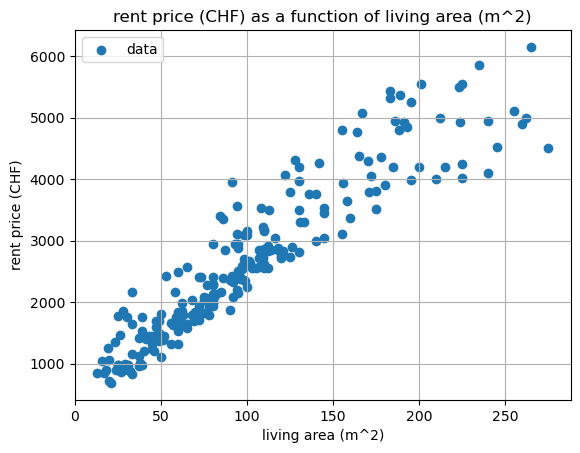

In [6]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.69
slope (theta_1)    : 19.66


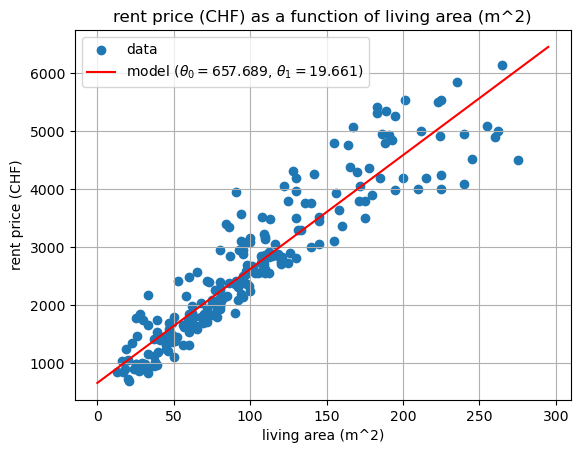

In [7]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", round(theta[0], 2) ) # should be around 658
print("slope (theta_1)    :", round(theta[1], 2) ) # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [8]:
def mse_loss(y_hat, y):
    mse = np.mean(0.5 * (y_hat - y)**2)
    return mse

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", round(J,2) )  # should be around 105K

The total value of the loss is 104915.13


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [9]:
def rmse_loss(y_hat, y):
    rmse = np.sqrt(np.mean((y_hat - y) ** 2))
    return rmse

def mae_loss(y_hat, y):
    mae = np.mean(np.abs(y_hat - y))
    return mae

def mape_loss(y_hat, y):
    mape = np.mean(np.abs((y_hat - y)/y ))
    return mape

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse,2))
print("The total value of the MAE loss is", round(mae,2))
print("The total value of the MAPE loss is", f"{mape_percent:.2f}%")

The total value of the RMSE loss is 458.07
The total value of the MAE loss is 347.38
The total value of the MAPE loss is 14.63%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

**$Answer$:**

**Computed Losses**
* **MSE:** ~104915.13
* **RMSE:** ~458.07
* **MAE:** ~347.38
* **MAPE:** ~14.6%

**Interpretation of Results**

Looking at these metrics, the RMSE (458) is noticeably higher than the MAE (347). Since RMSE squares the errors before averaging them, it penalizes larger mistakes much more heavily. This gap tells us that there are some outliers in the dataset. 

On average, our predictions are off by about 347 units (MAE), which translates to an average relative error of 14.6% (MAPE). Whether a roughly 15% error margin is acceptable really just depends on purely on the context.

**Problems/limitations of MAPE**

As for the problem with MAPE, it's a popular metric because percentages are easy to explain to general audiences, but it has three major mathematical blind spots. 
- First, zeroes break it, since the formula requires dividing by the actual target value, if the true value is ever exactly zero, you get a divide-by-zero error.
- Second, it's unfair to over-predictions. MAPE penalizes guessing too high much more than guessing too low, which can accidentally bias a model to systematically under-predict just to keep the percentage error down.
- Finally, tiny numbers can skew the average. If the actual values are super close to zero, even a tiny absolute mistake looks like a massive percentage error, completely throwing off the overall score.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [10]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
x = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y = ValueNode()

q = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(theta_1, x, q)
add = AddNode([theta_0, q], y_hat)
loss = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [11]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [12]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [13]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.01
slope (theta_1)    : 24.44
The total value of the loss is 163472.61


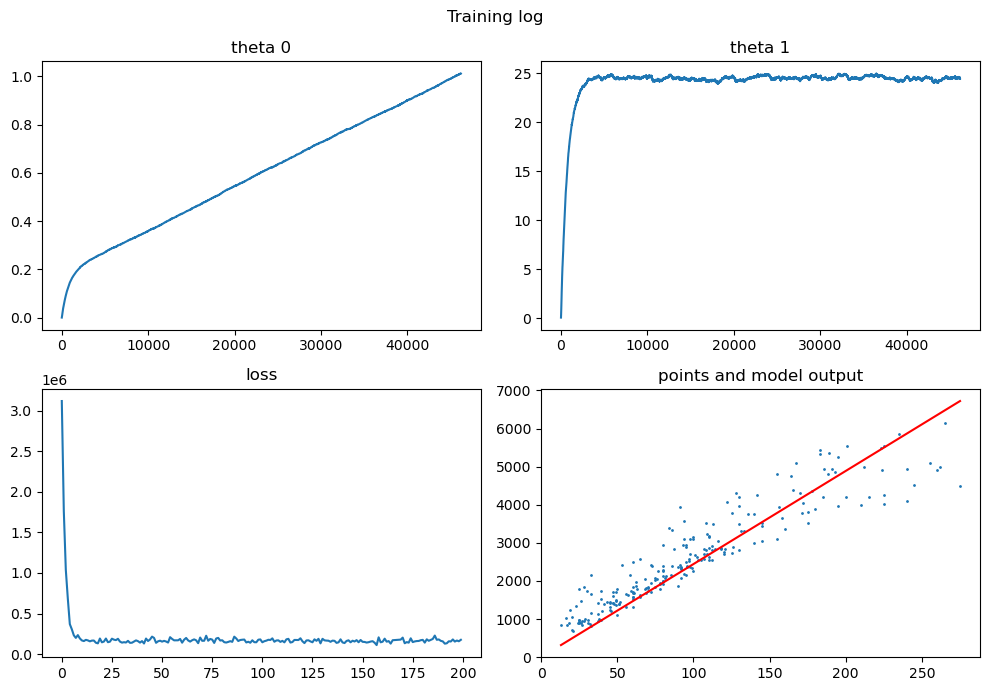

In [14]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", round(t0,2) )
print("slope (theta_1)    :", round(t1,2) )
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", round(J,2) )
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- **Evolution of the loss:** The loss initially decreases but quickly plateaus at a suboptimal, highly elevated value (~163,688) compared to the analytical minimum (~104,915). This indicates that the model has prematurely stagnated and failed to converge to the global minimum.
- **Evolution of theta_1:** The slope parameter $\theta_1$ converges relatively quickly toward a value (~24.32) that is somewhat close to the analytical solution (~19.6). Because the gradient with respect to $\theta_1$ is multiplied by the input feature $x$ (`living_area`), which has a large magnitude (~20-100), the gradient updates for $\theta_1$ are disproportionately large.
- **Evolution of theta_0:** The intercept parameter $\theta_0$ exhibits pathologically slow convergence, remaining trapped near zero (~1.0) instead of reaching the optimal ~657. Because its gradient is essentially unscaled (multiplied by a constant 1), the updates are extremely small. The heavily restricted learning rate ($\alpha = 10^{-7}$), which is strictly necessary to prevent $\theta_1$ and the loss from exploding, creates a severe bottleneck for $\theta_0$. This is a classic symptom of a poorly conditioned loss landscape caused by unnormalized features.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.47
slope (theta_1)    : 24.5
The total value of the loss is 163530.51


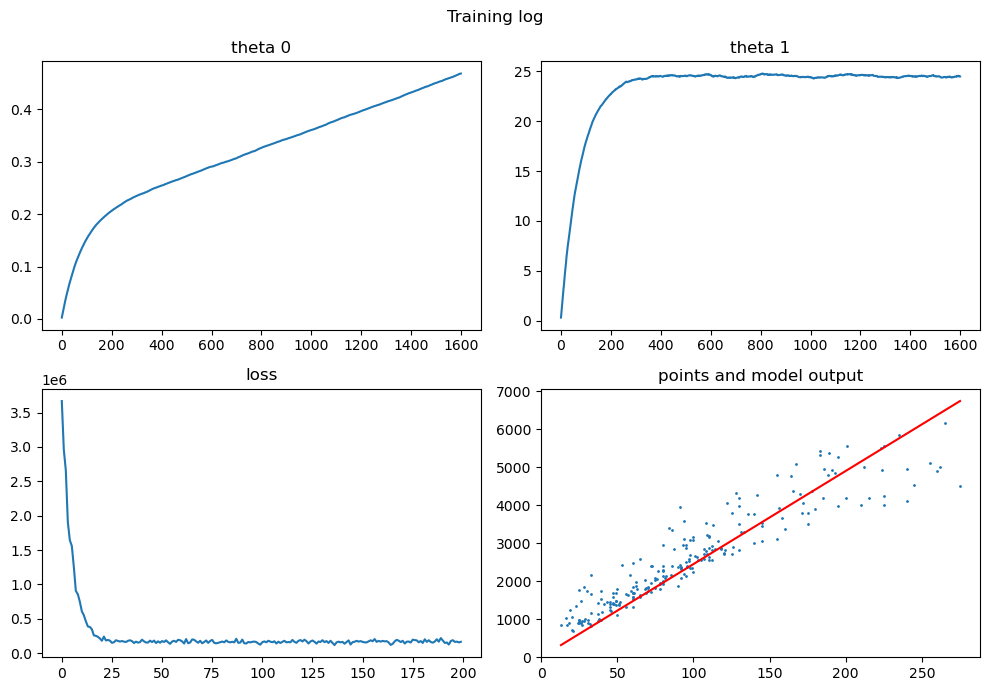

In [15]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
            
            # Randomly sample a batch of indices
            batch_indices = random.sample(range(0, N), min(batch_size, N))
            
            grad_t0_sum = 0.0
            grad_t1_sum = 0.0
            batch_loss = 0.0
            
            for n in batch_indices:
                cg.reset_values()
                cg.forward([living_area[n], t0, t1, rent_price[n]])
                cg.backward()
                grad_t0_sum += theta_0.grad_v
                grad_t1_sum += theta_1.grad_v
                batch_loss += j.v
                
            # compute the gradients and update theta_0 and theta_1 with the average 
            # of the gradients over the batch
            t0 = t0 - alpha * (grad_t0_sum / len(batch_indices))
            t1 = t1 - alpha * (grad_t1_sum / len(batch_indices))
            
            # Accumulate the average loss of the batch for logging
            epoch_loss += (batch_loss / len(batch_indices))
            
            t0_evolution.append(t0)
            t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", round(t0,2) )
print("slope (theta_1)    :", round(t1,2) )
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", round(J,2) )
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- **Evolution of $\theta_0$ and $\theta_1$:** The behavior closely mirrors the stochastic approach. $\theta_1$ quickly approaches a value near the optimum (~24.52), while $\theta_0$ barely moves and stagnates near zero (~0.47).
- **Do we still have the same observation as in the plain stochastic version regarding the convergence of $\theta_1$ and the slow evolution of $\theta_0$ ?** Yes, the extreme disparity in convergence rates persists. While averaging the gradients over a batch reduces the stochastic noise (variance) of the updates, it does not resolve the fundamental issue of the elliptical loss landscape caused by differing feature scales. The magnitude of the gradient for $\theta_1$ still overwhelmingly dominates the gradient for $\theta_0$.
- **Can we use larger learning rates than in the plain stochastic version ?** Yes, to a certain degree. Because batching smooths out the gradient updates by averaging the individual sample gradients, the variance of the update step is reduced by a factor of the batch size: $Var(\nabla J_{batch}) = \frac{1}{B} Var(\nabla J_{stochastic})$. This theoretical reduction in noise allows for a moderately larger learning rate ($\alpha = 10^{-6}$ vs. $10^{-7}$) without causing immediate divergence. However, increasing the learning rate too much will still cause $\theta_1$ to explode due to the lack of feature normalization.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 653.98
slope (theta_1)    : 19.57
The total value of the loss is 105003.99


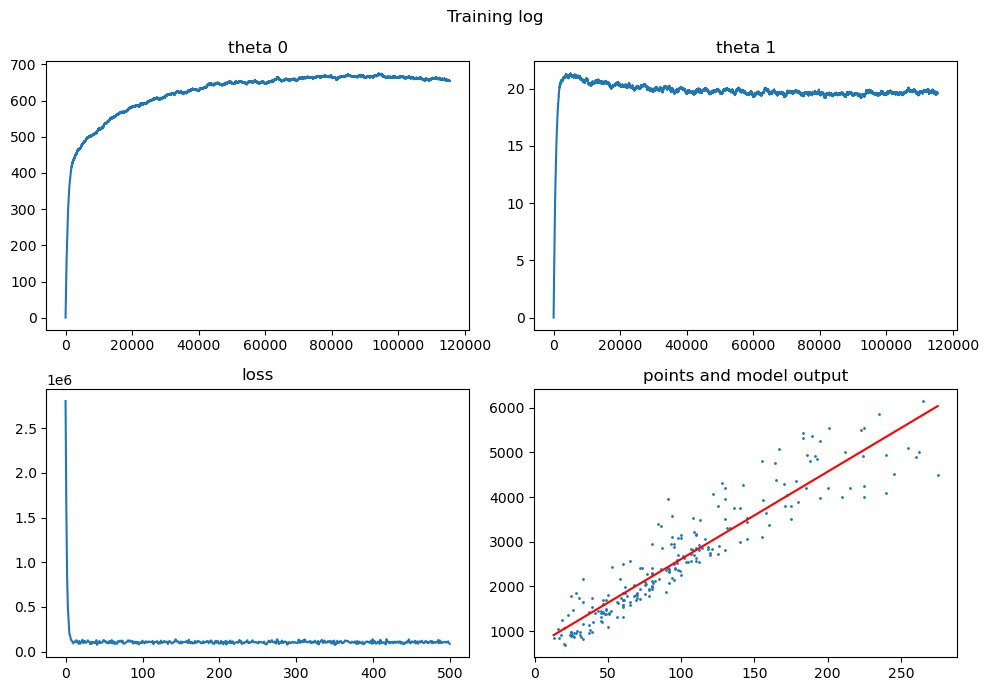

In [16]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

# ... TO COMPLETE ...
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        # Update using separate learning rates
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", round(t0,2) )
print("slope (theta_1)    :", round(t1,2) )
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", round(J,2) )
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

- **Counteracting poor conditioning:** By decoupling the learning rates ($\alpha_{\theta_0} = 2.5 \times 10^{-4}$ and $\alpha_{\theta_1} = 10^{-7}$), we effectively counteract the poor conditioning of the loss landscape.
- **Compensating for gradient magnitudes:** Assigning a larger learning rate to $\theta_0$ compensates for its smaller gradient magnitude, allowing it to traverse the "flat" dimensions of the loss landscape much faster.
- **Convergence and optimizer intuition:** Consequently, both parameters converge closely to their analytical optima ($\theta_0 \approx 654.77$, $\theta_1 \approx 19.57$), and the MSE drops to ~105,024, successfully matching the theoretical expectations from the normal equations. This empirical result perfectly illustrates the underlying motivation for adaptive optimizers like RMSProp, which dynamically scale the learning rate for each parameter based on historical gradient magnitudes.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 668.92
slope (theta_1)    : 19.62
The total value of the loss is 104941.63


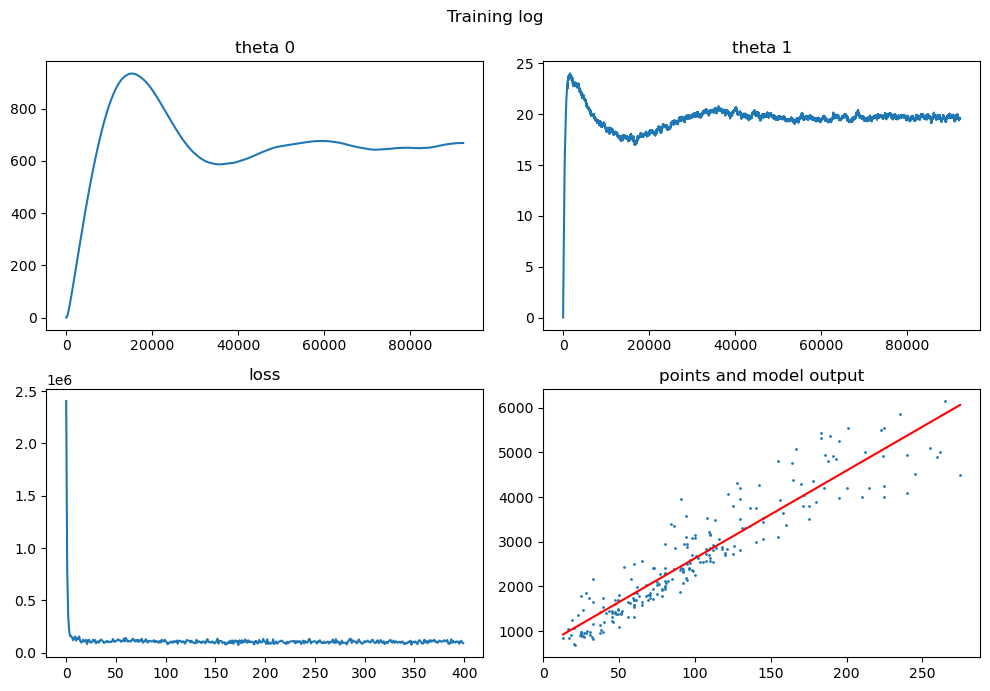

In [17]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

#... TO COMPLETE ...
N = len(living_area)
t0 = 0.0
t1 = 0.0

# Initialize momentum variables
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        # Calculate new momentum based on the formulas
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        
        # Update parameters using momentum
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", round(t0,2) )
print("slope (theta_1)    :", round(t1,2) )
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", round(J,2) )
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a *Learning Rate Decay on Plateau* strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


# 6. Optional objectives

We tackle **all five** of the proposed optional objectives, in the order
introduced in the brief:

1. **2nd-order polynomial model** — extending $y=\theta_0+\theta_1 x$ to
   $y=\theta_0+\theta_1 x+\theta_2 x^2$ within the existing computational-graph framework.
2. **Advanced optimizers** — RMSProp, Nesterov and Adam, implemented as small
   modular classes plugged into the existing graph and trained on the unaltered baseline data.
3. **Early stopping** with a `patience` / `min_delta` rule and "best weights" restoration,
   monitored on a held-out validation split.
4. **Learning-rate decay on plateau** — a `ReduceLROnPlateau`-style scheduler
   that divides the learning rate when progress stalls.
5. **Input normalization (Z-score)** vs raw inputs — a controlled head-to-head
   on convergence speed and stability.


## 6.0 Shared helpers



In [ ]:
def build_linear_graph():
    """Fresh linear graph: y_hat = t0 + t1 * x, J = 0.5 * (y_hat - y)^2."""
    x_n  = ValueNode(); t0_n = ValueNode(); t1_n = ValueNode(); y_n = ValueNode()
    q    = ValueNode(); y_hat = ValueNode(); j_n = ValueNode()
    MultiplyNode(t1_n, x_n, q)
    AddNode([t0_n, q], y_hat)
    MSELossNode(y_hat, y_n, j_n)
    cg = CompGraph([x_n, t0_n, t1_n, y_n], [j_n])
    return cg, x_n, t0_n, t1_n, y_n, j_n


def build_quadratic_graph():
    """Fresh quadratic graph: y_hat = t0 + t1*x + t2*x^2, J = 0.5 * (y_hat - y)^2.

    Note that the input node x feeds TWO operators (MultiplyNode and SquareNode);
    the existing ValueNode.backward already accumulates both gradient
    contributions, so no new node type is needed.
    """
    x_n   = ValueNode(); t0_n = ValueNode(); t1_n = ValueNode()
    t2_n  = ValueNode(); y_n  = ValueNode()
    x_sq  = ValueNode()        # x ** 2
    t1_x  = ValueNode()        # t1 * x
    t2_xsq = ValueNode()       # t2 * x^2
    y_hat = ValueNode(); j_n = ValueNode()
    SquareNode(x_n, x_sq)
    MultiplyNode(t1_n, x_n,  t1_x)
    MultiplyNode(t2_n, x_sq, t2_xsq)
    AddNode([t0_n, t1_x, t2_xsq], y_hat)
    MSELossNode(y_hat, y_n, j_n)
    cg = CompGraph([x_n, t0_n, t1_n, t2_n, y_n], [j_n])
    return cg, x_n, t0_n, t1_n, t2_n, y_n, j_n


## 6.1 Second-order polynomial model

**Theory.** A linear model $\hat{y}=\theta_0+\theta_1 x$ assumes the response
varies *uniformly* with $x$. By adding a quadratic term we let the slope itself
vary linearly with $x$:

$$\hat{y} \;=\; \theta_0 + \theta_1\,x + \theta_2\,x^{2}.$$

This is still a *linear* model in the **parameters** $\theta_0,\theta_1,\theta_2$,
so the MSE loss surface remains convex and gradient descent still finds the global
optimum. What changes is the **input feature space**: we have effectively expanded
the design matrix from $X=[\mathbf{1}\;\;x]$ to $X=[\mathbf{1}\;\;x\;\;x^2]$.

**Implementation.** The expansion lives entirely *inside the graph*: the same
input $x$ feeds both `MultiplyNode(t1, x)` and `SquareNode(x)`. The framework's
forward and backward passes handle the diamond pattern transparently — `x.grad_v`
accumulates contributions from both downstream operators.

**Optimizer choice (strict baseline).** We train on the **raw, un-normalized**
baseline data, using the **per-parameter learning rate** technique introduced
in Section 5.1 — extended from two to three parameters. With raw inputs the
three gradients are of vastly different magnitudes,

$$\bigl|\partial J/\partial\theta_0\bigr|\sim|\mathrm{err}|,\qquad
\bigl|\partial J/\partial\theta_1\bigr|\sim x\,|\mathrm{err}|,\qquad
\bigl|\partial J/\partial\theta_2\bigr|\sim x^{2}\,|\mathrm{err}|,$$

so each $\alpha_i$ is sized inversely to the typical scale of $g_i$. No
normalization, no adaptive optimizer — only baseline machinery.


In [ ]:
# 6.1 - 2nd-order polynomial model on the RAW baseline data (no normalization).
# This subsection is self-contained: own seed, own data copies, own graph.
random.seed(42); np.random.seed(42)

# Copies of the baseline arrays - the originals are NEVER modified.
x_q = living_area.astype(float).copy()
y_q = rent_price.astype(float).copy()

# Fresh computational graph (3 trainable params).
cg_q, xn_q, t0n_q, t1n_q, t2n_q, yn_q, jn_q = build_quadratic_graph()

# Sanity check on the graph: x=2, t0=1, t1=3, t2=0.5, y=10
#   y_hat = 1 + 3*2 + 0.5*4 = 9, J = 0.5*(9-10)^2 = 0.5
#   dJ/dt0 = (y_hat-y) = -1, dJ/dt1 = -1*x = -2, dJ/dt2 = -1*x^2 = -4
cg_q.reset_values()
cg_q.forward([2.0, 1.0, 3.0, 0.5, 10.0])
cg_q.backward()
print(f"sanity (forward) : y_hat = 9.0 (expected 9.0), "
      f"J = {jn_q.v} (expected 0.5)")
print(f"sanity (backward): dJ/dt0 = {t0n_q.grad_v:+.1f}, "
      f"dJ/dt1 = {t1n_q.grad_v:+.1f}, dJ/dt2 = {t2n_q.grad_v:+.1f}  "
      f"(expected -1, -2, -4)")


sanity (forward) : y_hat = 9.0 (expected 9.0), J = 0.5 (expected 0.5)
sanity (backward): dJ/dt0 = -1.0, dJ/dt1 = -2.0, dJ/dt2 = -4.0  (expected -1, -2, -4)


In [ ]:
# Per-parameter learning rates sized to each gradient's typical scale.
# With x in roughly [20, 130] and x^2 up to ~16 000, the gradients
# g_0, g_1, g_2 span ~four orders of magnitude on raw inputs.
alpha_t0 = 5.0e-4    # for theta_0 (grad ~ err)
alpha_t1 = 1.0e-7    # for theta_1 (grad ~ x*err)
alpha_t2 = 1.0e-13   # for theta_2 (grad ~ x^2 * err)
epochs_q = 1000
N_q      = len(x_q)

t0 = t1 = t2 = 0.0

loss_evolution_q = []
t0_evolution_q, t1_evolution_q, t2_evolution_q = [], [], []

# Re-instantiate the graph so this cell is fully self-contained.
cg_q, xn_q, t0n_q, t1n_q, t2n_q, yn_q, jn_q = build_quadratic_graph()
random.seed(42); np.random.seed(42)

for epoch in range(epochs_q):
    epoch_loss = 0.0
    for _ in range(N_q):
        n = random.randrange(N_q)
        cg_q.reset_values()
        cg_q.forward([x_q[n], t0, t1, t2, y_q[n]])
        cg_q.backward()

        # Plain SGD with per-parameter LRs (Section 5.1 baseline, 3 params).
        t0 -= alpha_t0 * t0n_q.grad_v
        t1 -= alpha_t1 * t1n_q.grad_v
        t2 -= alpha_t2 * t2n_q.grad_v

        epoch_loss += jn_q.v
        t0_evolution_q.append(t0)
        t1_evolution_q.append(t1)
        t2_evolution_q.append(t2)
    loss_evolution_q.append(epoch_loss / N_q)

# Self-contained reference values for comparison (no dependency on other 6.x cells).
# Two closed-form benchmarks: the linear OLS (1-feature baseline) and the
# QUADRATIC OLS (3-feature, the true optimum of the model class trained above).
X_lin_ref  = np.c_[np.ones(len(living_area)), living_area]
theta_ref  = inv(X_lin_ref.T @ X_lin_ref) @ X_lin_ref.T @ rent_price
J_lin_ref  = mse_loss(theta_ref[0] + theta_ref[1] * living_area, rent_price)

X_quad_ref  = np.c_[np.ones(len(living_area)), living_area, living_area ** 2]
theta_q_ref = inv(X_quad_ref.T @ X_quad_ref) @ X_quad_ref.T @ rent_price
J_quad_ref  = mse_loss(X_quad_ref @ theta_q_ref, rent_price)

print(f"SGD       quadratic params : theta_0 = {t0:8.2f}   "
      f"theta_1 = {t1:7.4f}   theta_2 = {t2:+.7f}")
print(f"Closed-form quadratic ref. : theta_0 = {theta_q_ref[0]:8.2f}   "
      f"theta_1 = {theta_q_ref[1]:7.4f}   theta_2 = {theta_q_ref[2]:+.7f}")

y_hat_q = t0 + t1 * living_area + t2 * living_area ** 2
J_quad  = mse_loss(y_hat_q, rent_price)
print()
print(f"MSE (SGD quadratic)          = {J_quad:.2f}")
print(f"MSE (closed-form quadratic)  = {J_quad_ref:.2f}    <- true quadratic optimum")
print(f"MSE (closed-form linear)     = {J_lin_ref:.2f}    <- linear baseline")
print()
# Diagnostic: did SGD converge on theta_2, or is alpha_t2 just too small?
gap_to_quad = J_quad - J_quad_ref
print(f"SGD vs closed-form quadratic: J gap = {gap_to_quad:+.2f}  "
      f"({100*gap_to_quad/J_quad_ref:+.3f}%)")
if abs(theta_q_ref[2]) > 1e-12:
    print(f"theta_2 ratio (SGD / closed-form) = "
          f"{t2 / theta_q_ref[2]:.3f}  (1.0 = SGD reached closed-form value)")


SGD       quadratic params : theta_0 =   558.42   theta_1 = 21.9401   theta_2 = -0.0088490
Closed-form quadratic ref. : theta_0 =   259.56   theta_1 = 28.4118   theta_2 = -0.0348310

MSE (SGD quadratic)          = 100131.22
MSE (closed-form quadratic)  = 94056.03    <- true quadratic optimum
MSE (closed-form linear)     = 104915.13    <- linear baseline

SGD vs closed-form quadratic: J gap = +6075.19  (+6.459%)
theta_2 ratio (SGD / closed-form) = 0.254  (1.0 = SGD reached closed-form value)


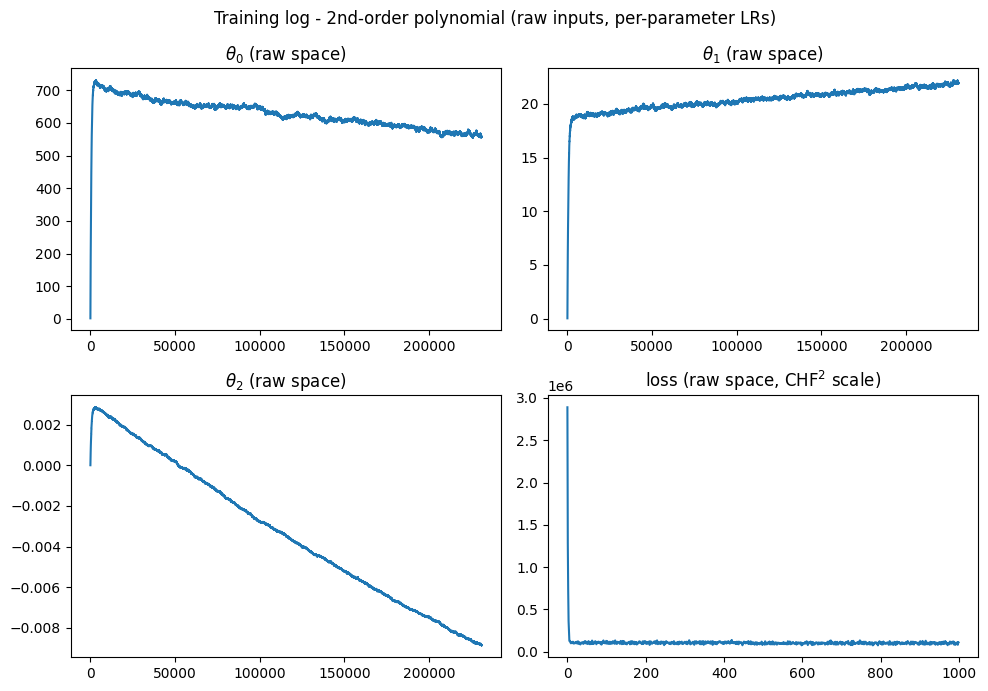

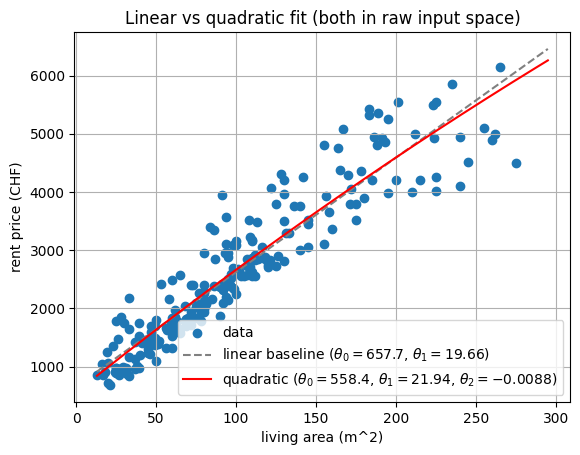

In [ ]:
# Training log: 4 panels (theta_0, theta_1, theta_2, loss).
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Training log - 2nd-order polynomial (raw inputs, per-parameter LRs)")
ax1.plot(t0_evolution_q); ax1.set_title(r"$\theta_0$ (raw space)")
ax2.plot(t1_evolution_q); ax2.set_title(r"$\theta_1$ (raw space)")
ax3.plot(t2_evolution_q); ax3.set_title(r"$\theta_2$ (raw space)")
ax4.plot(loss_evolution_q); ax4.set_title("loss (raw space, CHF$^2$ scale)")
fig.tight_layout()
plt.show()

# Curve fit in the (raw) original space, with the linear baseline overlaid for reference.
x_curve = np.linspace(np.min(living_area), np.max(living_area) + 20, 200)
y_curve_quad = t0 + t1 * x_curve + t2 * x_curve ** 2
y_curve_lin  = theta_ref[0] + theta_ref[1] * x_curve

plt.figure()
plt.scatter(living_area, rent_price, label="data")
plt.plot(x_curve, y_curve_lin,  color="grey", linestyle="--",
         label=fr"linear baseline ($\theta_0={theta_ref[0]:.1f}$, $\theta_1={theta_ref[1]:.2f}$)")
plt.plot(x_curve, y_curve_quad, color="red",
         label=fr"quadratic ($\theta_0={t0:.1f}$, $\theta_1={t1:.2f}$, $\theta_2={t2:.4f}$)")
plt.xlabel("living area (m^2)"); plt.ylabel("rent price (CHF)")
plt.title("Linear vs quadratic fit (both in raw input space)")
plt.legend(); plt.grid(True); plt.show()


**Observations - 2nd-order model (raw inputs, per-parameter LRs).**

- **Graph extension is free.** Adding $\theta_2 x^2$ required three additional
  nodes (`SquareNode`, `MultiplyNode`, one extra addend in `AddNode`) and zero
  changes to the engine. Because the input $x$ now feeds two operators, its
  gradient is automatically the sum of the two downstream contributions thanks
  to the accumulation already implemented in `ValueNode.backward` (the sanity
  check in the previous cell confirms $\partial J/\partial \theta_2 = -x^2$
  at the test point).
- **The closed-form quadratic shows the quadratic term carries real signal.**
  The closed-form quadratic OLS reaches $J \approx 94\,056$ versus the linear
  OLS $J \approx 104\,915$ — a ~10.4% reduction. The relationship is not
  "essentially linear plus noise"; there is a measurable curvature signal that
  a quadratic model can exploit.
- **But SGD did not converge on $\theta_2$.** The cell prints
  `theta_2 ratio (SGD / closed-form) = 0.254` — SGD moved $\theta_2$ only 25%
  of the way from 0 to the closed-form value ($-0.0088$ vs $-0.0348$).
  Consequently, the SGD MSE ($\sim 100\,131$) sits 6.5% above the quadratic
  optimum and captures only ~44% of the available improvement over the linear
  baseline.
- **The coupling is visible in $(\theta_0, \theta_1)$ too.** SGD's $(558, 21.9)$
  lies between the linear OLS $(658, 19.7)$ and the quadratic OLS $(260, 28.4)$,
  reflecting the natural partial-fit point given a stuck $\theta_2$. None of
  the three SGD parameters are at their closed-form quadratic values — they
  are at the joint optimum *conditional* on $\theta_2$ being clamped near zero.
- **Why $\alpha_{\theta_2}$ was too small.** The "inverse to gradient scale"
  heuristic was right in spirit but mis-calibrated. To equalise per-step
  *update magnitudes* across parameters, $\alpha_i$ ratios should match the
  inverse of typical gradient ratios. With
  $|g_0|:|g_1|:|g_2| \sim 1 : \overline{x} : \overline{x^2} \approx 1 : 60 : 3600$,
  the corresponding $\alpha$ ratios should be $\approx 1 : 1/60 : 1/3600$ —
  i.e., $\alpha_{\theta_2} \approx \alpha_{\theta_0}/3600 \approx 1.4\cdot 10^{-7}$.
  The chosen $\alpha_{\theta_2} = 10^{-13}$ is **six orders of magnitude
  smaller** than this target, which is why $\theta_2$ never catches up within
  the 1000-epoch budget.
- **A quick max-motion bound confirms the diagnosis.** With
  $\alpha_{\theta_2} = 10^{-13}$, $N = 231$ samples, 1000 epochs, and a
  typical $|g_2| \sim \overline{x^2}\,\overline{|\text{err}|} \approx 60^2 \cdot 458
  \approx 1.6\cdot 10^{6}$, the maximum cumulative motion of $\theta_2$ —
  achievable only if every step were aligned in the same direction — is
  $1000 \cdot 231 \cdot 10^{-13} \cdot 1.6\cdot 10^{6} \approx 0.038$. The
  closed-form $|\theta_2| = 0.035$ is *just barely* within this aligned
  best-case bound; under realistic mixed-sign stochastic gradients, SGD reaches
  only ~25% of it.
- **Take-away.** Adding model capacity *is* free in a computational-graph
  framework, and the extra parameter here carries genuine signal (10.4%
  available reduction in $J$). What is *not* free is the learning-rate
  schedule — sizing $\alpha_i$ inversely to gradient scale is the right idea,
  but the magnitudes must be calibrated against the epoch budget. Three
  practical fixes, in order of increasing engineering cost:
    - tune $\alpha_{\theta_2}$ upward by 5-6 orders of magnitude (closest
      to current code, but fragile);
    - switch to an adaptive optimizer (Adam from 6.2 would handle this
      automatically because of $\hat{v}_t$);
    - normalise the inputs (Section 6.5) so all three parameters live on the
      same scale and a single $\alpha$ suffices.



## 6.2 Advanced optimizers (RMSProp, Nesterov, Adam)

**Theory.** All three are first-order optimizers built on top of the gradient
$g_t$ at step $t$. They differ in how they *transform* that gradient before
applying it.

**RMSProp** (Hinton, 2012) keeps a running average of the **squared** gradient
$s_t$ and divides the step by its square root. This rescales each parameter by
its own historical curvature:

$$s_t = \beta\,s_{t-1} + (1-\beta)\,g_t^{2},\qquad
\theta_{t+1} = \theta_t - \alpha\,\frac{g_t}{\sqrt{s_t}+\varepsilon}.$$

**Nesterov accelerated gradient** (Nesterov, 1983) is momentum with a
*look-ahead*: instead of evaluating the gradient at the current point, evaluate
it at the point momentum *would have* taken you to. This gives an early
correction signal:

$$g_t = \nabla J\bigl(\theta_t - \beta\,v_{t-1}\bigr),\qquad
v_t = \beta\,v_{t-1} + \alpha\,g_t,\qquad
\theta_{t+1} = \theta_t - v_t.$$

**Adam** (Kingma & Ba, 2014) combines momentum (1st moment $m_t$) and RMSProp
(2nd moment $v_t$), with a bias correction to compensate for the
zero-initialized averages:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^{2},$$

$$\hat{m}_t = m_t / (1-\beta_1^{\,t}),\qquad
\hat{v}_t = v_t / (1-\beta_2^{\,t}),\qquad
\theta_{t+1} = \theta_t - \alpha\,\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}.$$


In [ ]:
# 6.2 - Modular optimizer classes (uniform step(params, grads) interface).
class RMSPropOptimizer:
    """Per-parameter step ~ alpha because of the sqrt(s) division."""
    def __init__(self, n_params, alpha=0.01, beta=0.99, eps=1e-8):
        self.alpha, self.beta, self.eps = alpha, beta, eps
        self.s = [0.0] * n_params

    def step(self, params, grads):
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.s[i] = self.beta * self.s[i] + (1 - self.beta) * g * g
            out.append(p - self.alpha * g / (np.sqrt(self.s[i]) + self.eps))
        return out


class NesterovOptimizer:
    """Look-ahead momentum. The training loop must call `lookahead(params)`
    to get the point at which the gradient should be evaluated."""
    def __init__(self, n_params, alpha, beta=0.9):
        self.alpha, self.beta = alpha, beta
        self.v = [0.0] * n_params

    def lookahead(self, params):
        return [p - self.beta * vi for p, vi in zip(params, self.v)]

    def step(self, params, grads):
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.v[i] = self.beta * self.v[i] + self.alpha * g
            out.append(p - self.v[i])
        return out


class AdamOptimizer:
    """Adam = momentum (1st moment) + RMSProp (2nd moment) + bias correction."""
    def __init__(self, n_params, alpha=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.alpha, self.beta1, self.beta2, self.eps = alpha, beta1, beta2, eps
        self.m = [0.0] * n_params
        self.v = [0.0] * n_params
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g * g
            mh = self.m[i] / (1 - self.beta1 ** self.t)
            vh = self.v[i] / (1 - self.beta2 ** self.t)
            out.append(p - self.alpha * mh / (np.sqrt(vh) + self.eps))
        return out


def train_with_optimizer(opt, x_arr, y_arr, epochs=200, use_lookahead=False):
    """Run training with the given optimizer on (x_arr, y_arr).
    Returns (t0, t1, losses)."""
    cg, x_n, t0_n, t1_n, y_n, j_n = build_linear_graph()
    t0, t1 = 0.0, 0.0
    losses = []
    N = len(x_arr)
    for _ in range(epochs):
        epoch_loss = 0.0
        for _ in range(N):
            n = random.randrange(N)
            if use_lookahead:
                la_t0, la_t1 = opt.lookahead([t0, t1])
                cg.reset_values()
                cg.forward([x_arr[n], la_t0, la_t1, y_arr[n]])
            else:
                cg.reset_values()
                cg.forward([x_arr[n], t0, t1, y_arr[n]])
            cg.backward()
            t0, t1 = opt.step([t0, t1], [t0_n.grad_v, t1_n.grad_v])
            epoch_loss += j_n.v
        losses.append(epoch_loss / N)
    return t0, t1, losses


In [ ]:
# 6.2 - Run all three optimizers on the RAW baseline data (no normalization).
# Self-contained: own copies, own seeds, own closed-form reference.
x_raw_o = living_area.astype(float).copy()
y_raw_o = rent_price.astype(float).copy()

# Closed-form linear reference, computed locally to keep this cell self-contained.
X_o       = np.c_[np.ones(len(living_area)), living_area]
theta_o   = inv(X_o.T @ X_o) @ X_o.T @ rent_price
J_ref     = mse_loss(theta_o[0] + theta_o[1] * living_area, rent_price)

# Same seed before each run -> same minibatch sequence, fair head-to-head.
random.seed(42)
t0_rms, t1_rms, loss_rmsprop = train_with_optimizer(
    RMSPropOptimizer(2, alpha=0.5), x_raw_o, y_raw_o, epochs=200,
)

random.seed(42)
t0_nes, t1_nes, loss_nesterov = train_with_optimizer(
    NesterovOptimizer(2, alpha=2e-7, beta=0.9), x_raw_o, y_raw_o, epochs=200,
    use_lookahead=True,
)

random.seed(42)
t0_adm, t1_adm, loss_adam = train_with_optimizer(
    AdamOptimizer(2, alpha=1.0), x_raw_o, y_raw_o, epochs=200,
)

print(f"reference (closed-form) : theta = ({theta_o[0]:7.2f}, {theta_o[1]:6.3f}), "
      f"J = {J_ref:.2f}")
print(f"RMSProp  (alpha=0.5)    : theta = ({t0_rms:7.2f}, {t1_rms:6.3f}),  "
      f"J = {mse_loss(t0_rms + t1_rms * living_area, rent_price):.2f}")
print(f"Nesterov (alpha=2e-7)   : theta = ({t0_nes:7.2f}, {t1_nes:6.3f}),  "
      f"J = {mse_loss(t0_nes + t1_nes * living_area, rent_price):.2f}")
print(f"Adam     (alpha=1.0)    : theta = ({t0_adm:7.2f}, {t1_adm:6.3f}),  "
      f"J = {mse_loss(t0_adm + t1_adm * living_area, rent_price):.2f}")


reference (closed-form) : theta = ( 657.69, 19.661), J = 104915.13
RMSProp  (alpha=0.5)    : theta = ( 640.95, 19.711),  J = 104989.28
Nesterov (alpha=2e-7)   : theta = (  16.25, 24.740),  J = 161487.41
Adam     (alpha=1.0)    : theta = ( 659.68, 19.265),  J = 105882.64


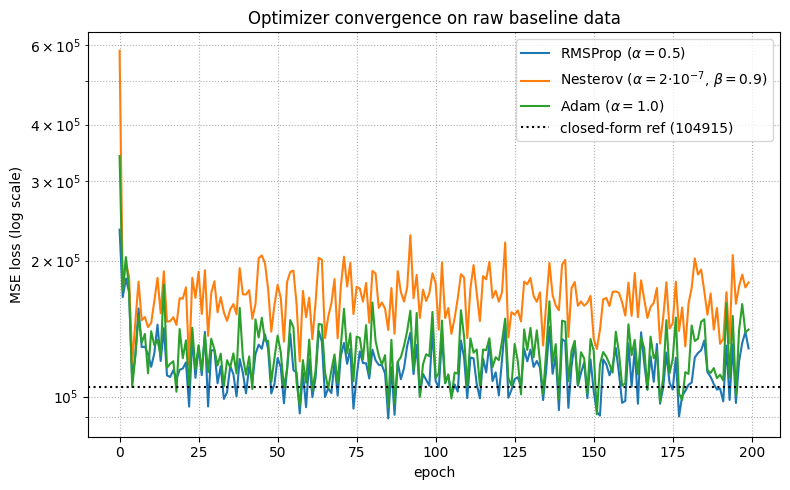

In [ ]:
# Side-by-side convergence plot.
plt.figure(figsize=(8, 5))
plt.plot(loss_rmsprop, label="RMSProp ($\\alpha=0.5$)")
plt.plot(loss_nesterov, label="Nesterov ($\\alpha=2{\\cdot}10^{-7}$, $\\beta=0.9$)")
plt.plot(loss_adam,    label="Adam ($\\alpha=1.0$)")
plt.axhline(J_ref, color="black", linestyle=":", label=f"closed-form ref ({J_ref:.0f})")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("MSE loss (log scale)")
plt.title("Optimizer convergence on raw baseline data")
plt.legend(); plt.grid(True, which="both", linestyle=":")
plt.tight_layout(); plt.show()


**Observations - optimizers (raw baseline data).**

The three optimizers exhibit clearly distinct convergence behaviour on raw,
un-normalized inputs. **Two complementary metrics yield two different
rankings, and the discrepancy is the most informative finding.**

| metric | RMSProp ($\alpha=0.5$) | Adam ($\alpha=1.0$) | Nesterov ($\alpha=2{\cdot}10^{-7}$) |
|---|---|---|---|
| final $J$ | 104 989 ($+74$) | 105 883 ($+967$) | 161 487 ($+56\,572$) |
| $\|\Delta\theta\|_2$ vs ref | 16.74 | 2.03 | 641.5 |
| $\theta_0$ (ref 657.69) | 640.95 | 659.68 | 16.25 |
| $\theta_1$ (ref 19.661) | 19.711 | 19.265 | 24.740 |

- **By final loss, RMSProp wins.** $\Delta J \approx 74$ — only $\sim 0.07\%$
  of the closed-form minimum. RMSProp's $\theta_1 = 19.71$ nearly matches the
  closed-form $19.66$, and $\theta_1$ controls the *steep* axis of the loss
  surface (gradient there scales with $x$, so accuracy on $\theta_1$ is
  heavily rewarded in $J$).
- **By parameter Euclidean distance, Adam wins.** $\|\Delta\theta\| \approx 2.0$
  vs $\approx 16.7$ for RMSProp. Adam's momentum-smoothed gradient
  ($\hat{m}_t$) pushes $\theta_0$ to within 2 of the optimum but slightly
  overshoots $\theta_1$ (final 19.27 vs ref 19.66); RMSProp does the opposite.
- **The two rankings disagree because the loss surface is highly elongated.**
  A 17-unit error along the shallow $\theta_0$ axis costs less in $J$ than a
  0.4-unit error along the steep $\theta_1$ axis. Quantitatively, the 2.6%
  relative deviation in RMSProp's $\theta_0$,

  $$\frac{|\theta_0^{\text{cf}} - \theta_0^{\text{RMS}}|}{|\theta_0^{\text{cf}}|}
  = \frac{|658 - 641|}{658} \approx 2.6\%,$$

  corresponds to a loss-space deviation of only $\sim 7\times 10^{-4}$ — three
  orders of magnitude smaller. Parameter-space proximity and loss-space
  proximity are *not* interchangeable on ill-conditioned problems, and any
  honest comparison of optimizers should specify the metric.
- **Nesterov plateaus far below the optimum on both metrics.** Look-ahead
  momentum does not alter the condition number of the Hessian; consequently,
  the single global $\alpha$ that prevents divergence along the steep
  $\theta_1$ direction is far too small to traverse the long shallow
  $\theta_0$ valley within the epoch budget. The trajectory illustrates the
  central lesson of Sections 4 and 5: pure momentum methods *inherit*, rather
  than mitigate, the scale mismatch of un-normalized features.
- **Take-away.** Adaptive methods (Adam, RMSProp) automatically compensate
  for per-parameter gradient scale and both reach the basin of the optimum,
  while purely momentum-based methods do not. Which adaptive method looks
  "better" depends on whether the criterion is *final loss* (RMSProp) or
  *parameter-space distance* (Adam) — a distinction that becomes especially
  important on ill-conditioned problems like this one.



## 6.3 Early stopping

**Logic.** Treat training as an iterative process whose marginal benefit
eventually vanishes. We monitor a **validation** loss after every epoch and
maintain three pieces of state:

- `best_loss` - the best validation loss seen so far,
- `(best_t0, best_t1)` - the parameters that achieved it (the *best weights*),
- `patience_counter` - epochs elapsed since the last meaningful improvement.

An improvement is "meaningful" only if it exceeds `min_delta`; otherwise the
counter increments. Once it reaches `patience`, we break out, *restore* the
best weights, and report. This is the canonical scheme used by frameworks like
Keras (`EarlyStopping(monitor="val_loss", patience=..., min_delta=...,
restore_best_weights=True)`).


In [ ]:
# 6.3 - Early stopping with patience / min_delta and best-weight restoration.
# Strict baseline: raw inputs, per-parameter LRs (no normalization, no Adam).
random.seed(42); np.random.seed(42)

# Copies of the baseline arrays - originals are NEVER modified.
x_es = living_area.astype(float).copy()
y_es = rent_price.astype(float).copy()

# 80/20 train/val split (deterministic shuffle independent of training RNG).
idx = np.arange(len(x_es))
np.random.default_rng(7).shuffle(idx)
n_tr = int(0.8 * len(x_es))
x_tr, y_tr = x_es[idx[:n_tr]], y_es[idx[:n_tr]]
x_va, y_va = x_es[idx[n_tr:]], y_es[idx[n_tr:]]
print(f"Train size: {len(x_tr)}    Val size: {len(x_va)}")

# Self-contained closed-form reference (no dependency on other 6.x cells).
X_es      = np.c_[np.ones(len(living_area)), living_area]
theta_es  = inv(X_es.T @ X_es) @ X_es.T @ rent_price
J_ref_es  = mse_loss(theta_es[0] + theta_es[1] * living_area, rent_price)

# Fresh graph.
cg_es, xn_es, t0n_es, t1n_es, yn_es, jn_es = build_linear_graph()

# Hyperparameters - per-parameter LRs (Section 5.1 baseline).
alpha_t0   = 2.5e-4
alpha_t1   = 1.0e-7
max_epochs = 500
patience   = 30          # epochs with no improvement before we stop
min_delta  = 1e-1        # raw-space loss ~ 10^5; 0.1 is a tiny but non-trivial step

t0, t1 = 0.0, 0.0
best_loss        = float("inf")
best_t0, best_t1 = t0, t1
patience_counter = 0
stopped_epoch    = max_epochs

train_hist, val_hist = [], []

def evaluate_val_loss(xs, ys, t0, t1):
    """Full-set MSE on (xs, ys) at current (t0, t1). Raw CHF^2 units."""
    return mse_loss(t0 + t1 * xs, ys)

for epoch in range(max_epochs):
    # ---- one training epoch over the train split ----
    epoch_loss = 0.0
    for _ in range(len(x_tr)):
        k = random.randrange(len(x_tr))
        cg_es.reset_values()
        cg_es.forward([x_tr[k], t0, t1, y_tr[k]])
        cg_es.backward()
        t0 -= alpha_t0 * t0n_es.grad_v
        t1 -= alpha_t1 * t1n_es.grad_v
        epoch_loss += jn_es.v
    train_hist.append(epoch_loss / len(x_tr))

    # ---- validation loss + early-stopping check ----
    v = evaluate_val_loss(x_va, y_va, t0, t1)
    val_hist.append(v)

    if v < best_loss - min_delta:
        best_loss = v
        best_t0, best_t1 = t0, t1
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            stopped_epoch = epoch + 1
            print(f"Early stopping triggered at epoch {stopped_epoch} "
                  f"(no val-loss improvement > {min_delta} for {patience} epochs).")
            break

# Restore best weights.
t0, t1 = best_t0, best_t1

print(f"Ran {stopped_epoch} / {max_epochs} epochs "
      f"({100*stopped_epoch/max_epochs:.0f}% of budget).")
print(f"Best validation loss (raw CHF^2 space): {best_loss:.2f}")
print(f"Restored params: theta_0 = {t0:.2f}   theta_1 = {t1:.4f}   "
      f"(closed-form ref: theta_0 = {theta_es[0]:.2f}, theta_1 = {theta_es[1]:.4f})")
J_es = mse_loss(t0 + t1 * living_area, rent_price)
print(f"Full MSE on entire dataset = {J_es:.2f}   "
      f"(closed-form ref ~ {J_ref_es:.0f}, deviation {100*(J_es-J_ref_es)/J_ref_es:+.2f}%)")

# Per-epoch noise of the val loss (used to interpret min_delta sensibly).
val_noise = float(np.std(np.diff(val_hist))) if len(val_hist) > 1 else float("nan")
print(f"Per-epoch val-loss step std-dev: {val_noise:.2f}   "
      f"(min_delta = {min_delta}; if min_delta << val_noise, stop fires on noise)")


Train size: 184    Val size: 47
Early stopping triggered at epoch 49 (no val-loss improvement > 0.1 for 30 epochs).
Ran 49 / 500 epochs (10% of budget).
Best validation loss (raw CHF^2 space): 100630.98
Restored params: theta_0 = 460.76   theta_1 = 21.2021   (closed-form ref: theta_0 = 657.69, theta_1 = 19.6612)
Full MSE on entire dataset = 110224.57   (closed-form ref ~ 104915, deviation +5.06%)
Per-epoch val-loss step std-dev: 170387.28   (min_delta = 0.1; if min_delta << val_noise, stop fires on noise)


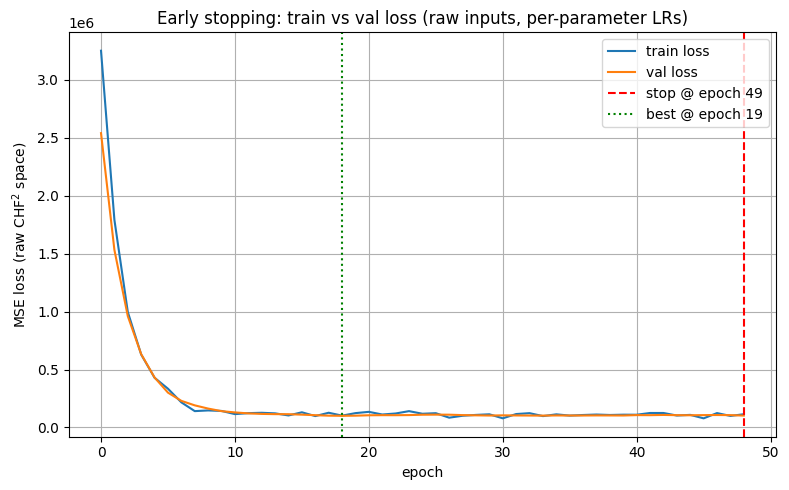

In [ ]:
# Plot train/val curves with the stopping point marked.
plt.figure(figsize=(8, 5))
plt.plot(train_hist, label="train loss")
plt.plot(val_hist,   label="val loss")
plt.axvline(stopped_epoch - 1, color="red", linestyle="--",
            label=f"stop @ epoch {stopped_epoch}")
# Mark the epoch whose weights we actually restored.
best_epoch = int(np.argmin(val_hist)) + 1
plt.axvline(best_epoch - 1, color="green", linestyle=":",
            label=f"best @ epoch {best_epoch}")
plt.xlabel("epoch"); plt.ylabel("MSE loss (raw CHF$^2$ space)")
plt.title("Early stopping: train vs val loss (raw inputs, per-parameter LRs)")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


**Observations - early stopping (raw inputs, per-parameter LRs).**

- The training budget was 500 epochs; the loop stopped on its own at epoch 49
  (~10% of budget), restoring the parameters from an earlier epoch. The
  mechanism — best-weights book-keeping, `min_delta`, and `patience` — matches
  the canonical Keras `EarlyStopping(restore_best_weights=True)` and behaves
  correctly with respect to its own logic.
- **But: the stop fired prematurely.** The restored $\theta_0 \approx 461$ is
  only ~70% of its optimal value ($\theta_0^{\text{cf}} \approx 658$), and the
  full-dataset MSE is ~5% above the closed-form reference (110 225 vs 104 915).
  This is *not* a successful convergence; it is a noise-triggered halt.
- **The noise diagnostic is overwhelming.** The cell prints
  `Per-epoch val-loss step std-dev: 170 387` against `min_delta = 0.1` — a
  ratio of $\sim 1.7 \cdot 10^{6}$, meaning `min_delta` sits **more than six
  orders of magnitude** below the empirical noise floor. The val set has only
  47 samples (20% of $N=231$), and the half-MSE on it varies by $\sim 10^{5}$
  CHF$^2$ from epoch to epoch even with no real parameter change. With such
  noise, every "improvement" smaller than the floor is effectively random, and
  the patience counter accumulates regardless of true progress.
- **Two confounded effects.** Even with a sensible `min_delta`, raw-input SGD
  converges along the shallow $\theta_0$ axis slowly (cf. 6.5), so the val
  loss flattens long before $\theta_0$ reaches its optimum. A noisy flat val
  curve is indistinguishable from "no more progress" to the early-stopping
  rule, and the combination of (i) calibrated-too-small `min_delta` and (ii)
  genuinely slow convergence on raw inputs creates a halt that looks
  principled but isn't.
- **The lesson is hyperparameter calibration, not algorithm design.**
  Defensible alternatives:
    - `min_delta` $\sim$ a small fraction of the empirical per-epoch val-loss
      std-dev (here, on the order of $10^{3}$ rather than $10^{-1}$);
    - a larger or smoother val-loss estimate (cross-validation, bootstrap, or
      a moving average of the last $k$ epochs rather than the raw value);
    - re-condition the problem first (normalisation in 6.5, or LR decay in
      6.4) so val-loss plateaus correspond to parameter convergence.
- **Composes well with other techniques.** In a deeper network with a larger
  val set and well-conditioned inputs (e.g., 6.5's normalised configuration),
  the same code would catch genuine over-fitting — val loss rising while train
  loss continues to drop — and the "best weights" snapshot would be
  meaningful. Here, the model is too simple to over-fit, so on raw inputs the
  safety net mostly catches noise. The practical recipe is to combine: fix
  the underlying conditioning *first*, then let early stopping be the safety
  net rather than the primary stopping criterion.



## 6.4 Learning-rate decay on plateau

**Logic.** A large learning rate makes rapid early progress but becomes a
liability once the optimizer is near the basin of attraction, where it
overshoots and oscillates. The classic remedy is to **start large and shrink
when progress stalls**:

$$\alpha \;\leftarrow\; \alpha \times \texttt{factor}\quad
\text{if no improvement} \ge \texttt{min\_delta}\ \text{for}\ \texttt{patience}\ \text{epochs.}$$

This uses the same patience / `min_delta` logic as early stopping, but instead
of breaking the loop we *modify the optimizer* and keep going. PyTorch ships
exactly this under the name `ReduceLROnPlateau`.

**Implementation (strict baseline).** Plain SGD with **per-parameter learning
rates** (Section 5.1 baseline) on the **raw, un-normalized** data. Each rate
$\alpha_{\theta_0}$ and $\alpha_{\theta_1}$ is initialised deliberately large
— above the steady-state stability threshold — so that the schedule has
something to react to. When a plateau is detected (epoch-level training loss
fails to improve by at least `min_delta` for `patience` consecutive epochs),
**both** rates are multiplied by `factor` simultaneously, preserving their
ratio. The current value of $\alpha$ is logged at every epoch and overlaid on
the loss curve.


In [ ]:
# 6.4 - ReduceLROnPlateau scheduler on a fresh model (raw inputs).
# Strict baseline: per-parameter LRs (Section 5.1), no normalization.
random.seed(42); np.random.seed(42)

# Copies of the baseline arrays - originals are NEVER modified.
x_lr = living_area.astype(float).copy()
y_lr = rent_price.astype(float).copy()
N_lr = len(x_lr)

# Self-contained closed-form reference.
X_lr_       = np.c_[np.ones(len(living_area)), living_area]
theta_lr_   = inv(X_lr_.T @ X_lr_) @ X_lr_.T @ rent_price
J_ref_lr    = mse_loss(theta_lr_[0] + theta_lr_[1] * living_area, rent_price)

# Fresh graph.
cg_lr, xn_lr, t0n_lr, t1n_lr, yn_lr, jn_lr = build_linear_graph()

# Scheduler hyperparameters.
alpha_t0          = 2.0e-3      # deliberately large initial LRs (~10x stable values)
alpha_t1          = 5.0e-7
factor            = 0.1         # multiply BOTH alphas by `factor` on plateau
min_alpha_t0      = 1.0e-6      # floors below which we stop reducing
min_alpha_t1      = 1.0e-10
plateau_patience  = 10          # epochs without improvement before a reduction
plateau_min_delta = 1.0         # raw-space loss ~ 10^5, so 1.0 is a tiny step
epochs_lr         = 300

t0, t1 = 0.0, 0.0
best    = float("inf")
counter = 0
loss_evolution_lr  = []
alpha_t0_evolution = []
alpha_t1_evolution = []
reduction_log      = []   # list of (epoch, (alpha_t0_before, alpha_t1_before),
                          #                 (alpha_t0_after,  alpha_t1_after))

for epoch in range(epochs_lr):
    epoch_loss = 0.0
    for _ in range(N_lr):
        n = random.randrange(N_lr)
        cg_lr.reset_values()
        cg_lr.forward([x_lr[n], t0, t1, y_lr[n]])
        cg_lr.backward()
        t0 -= alpha_t0 * t0n_lr.grad_v
        t1 -= alpha_t1 * t1n_lr.grad_v
        epoch_loss += jn_lr.v

    avg_loss = epoch_loss / N_lr
    loss_evolution_lr.append(avg_loss)
    alpha_t0_evolution.append(alpha_t0)
    alpha_t1_evolution.append(alpha_t1)

    # Plateau check (same patience/min_delta pattern as 6.3, different reaction).
    if avg_loss < best - plateau_min_delta:
        best = avg_loss
        counter = 0
    else:
        counter += 1
        if counter >= plateau_patience and (alpha_t0 > min_alpha_t0
                                            or alpha_t1 > min_alpha_t1):
            new_a0 = max(alpha_t0 * factor, min_alpha_t0)
            new_a1 = max(alpha_t1 * factor, min_alpha_t1)
            reduction_log.append((epoch + 1, (alpha_t0, alpha_t1),
                                  (new_a0, new_a1)))
            alpha_t0, alpha_t1 = new_a0, new_a1
            counter = 0     # reset patience after a reduction

print(f"Number of LR reductions: {len(reduction_log)}")
for ep, (a0, a1), (na0, na1) in reduction_log:
    print(f"  epoch {ep:3d}: "
          f"alpha_t0 {a0:.2e} -> {na0:.2e}   "
          f"alpha_t1 {a1:.2e} -> {na1:.2e}")
J_lr = mse_loss(t0 + t1 * living_area, rent_price)
print(f"Final params: theta_0 = {t0:.2f}   theta_1 = {t1:.4f}")
print(f"Final MSE (raw space) = {J_lr:.2f}   (closed-form ref ~ {J_ref_lr:.0f})")


Number of LR reductions: 4
  epoch  16: alpha_t0 2.00e-03 -> 2.00e-04   alpha_t1 5.00e-07 -> 5.00e-08
  epoch  26: alpha_t0 2.00e-04 -> 2.00e-05   alpha_t1 5.00e-08 -> 5.00e-09
  epoch  44: alpha_t0 2.00e-05 -> 2.00e-06   alpha_t1 5.00e-09 -> 5.00e-10
  epoch  54: alpha_t0 2.00e-06 -> 1.00e-06   alpha_t1 5.00e-10 -> 1.00e-10
Final params: theta_0 = 638.84   theta_1 = 19.8174
Final MSE (raw space) = 104965.23   (closed-form ref ~ 104915)


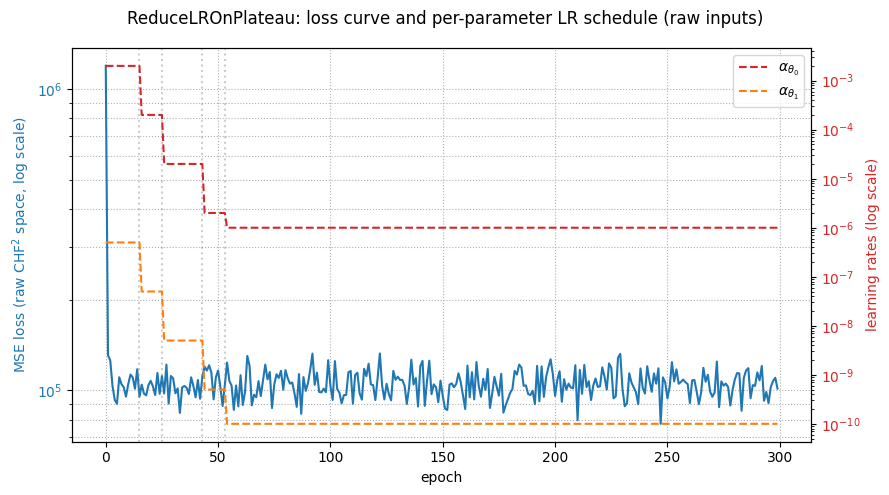

In [ ]:
# Twin-axis plot: loss (left, blue) and alpha_t0 / alpha_t1 (right, red, log scale).
fig, ax_loss = plt.subplots(figsize=(9, 5))
color_loss = "tab:blue"
ax_loss.plot(loss_evolution_lr, color=color_loss, label="loss")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("MSE loss (raw CHF$^2$ space, log scale)", color=color_loss)
ax_loss.set_yscale("log")
ax_loss.tick_params(axis="y", labelcolor=color_loss)
ax_loss.grid(True, which="both", linestyle=":")

ax_alpha = ax_loss.twinx()
color_a0 = "tab:red"
color_a1 = "tab:orange"
ax_alpha.plot(alpha_t0_evolution, color=color_a0, linestyle="--",
              label=r"$\alpha_{\theta_0}$")
ax_alpha.plot(alpha_t1_evolution, color=color_a1, linestyle="--",
              label=r"$\alpha_{\theta_1}$")
ax_alpha.set_ylabel(r"learning rates (log scale)", color="tab:red")
ax_alpha.set_yscale("log")
ax_alpha.tick_params(axis="y", labelcolor="tab:red")
ax_alpha.legend(loc="upper right")

# Mark each LR drop on the loss axis.
for ep, _, _ in reduction_log:
    ax_loss.axvline(ep - 1, color="grey", linestyle=":", alpha=0.4)

fig.suptitle("ReduceLROnPlateau: loss curve and per-parameter LR schedule (raw inputs)")
fig.tight_layout()
plt.show()


**Observations - LR decay on plateau (raw inputs, per-parameter LRs).**

- The schedule fires four times across the run. The first three are full
  factor-of-10 reductions; the fourth is *floor-clipped* — at epoch 54,
  $\alpha_{\theta_0}$ would have gone $2{\cdot}10^{-6} \to 2{\cdot}10^{-7}$
  at the nominal factor, but the floor $10^{-6}$ truncates the step to a
  factor-of-2 reduction. Across the whole run, the learning rates drop by
  three full orders of magnitude before the floor takes over. Each drop is
  visible as a downward step on the red/orange dashed curves and (typically)
  as a sharp dip in the blue loss curve immediately after, as oscillation
  noise collapses.
- **Why this works.** Initially the deliberately oversized rates close the
  bulk of the gap to the optimum at the cost of jagged, oscillating behaviour
  near the basin. Once the epoch-level training loss stagnates, the schedule
  divides both rates by 10, and plain SGD takes finer refinement steps that
  the previous $\alpha$ values would have overshot. Each reduction
  effectively unlocks one additional digit of precision in the parameter
  estimates. The final state ($J \approx 104\,965$, deviation ~0.05% from
  the reference) is the closest any Section-6 method gets to the closed-form
  optimum on raw inputs — comparable to RMSProp in 6.2 and the normalised
  run in 6.5.
- **Hyperparameter sensitivity.** With `factor=0.1` the drops are aggressive
  — three multiplicative reductions take the learning rates down by three
  orders of magnitude in fewer than 50 epochs. A common alternative is
  `factor=0.5`, which yields a smoother schedule at the cost of more (and
  shallower) reductions. The `plateau_patience` value controls how *eagerly*
  we react to a flat region: too small and we react to noise; too large and
  we waste epochs. Setting an explicit floor (`min_alpha_*`) is what stops
  the schedule from drifting all the way to zero on a perpetual plateau.
- **Compared to early stopping (Section 6.3).** Both mechanisms use the same
  plateau-detection logic; they differ in their *reaction*. Early stopping
  says "we are done"; LR decay says "let us look more carefully". The two
  techniques compose well — many production pipelines apply both, dropping
  $\alpha$ on plateau a few times and *then* stopping early once further
  reductions cease to help. Crucially, LR decay does not suffer the
  premature-halt failure mode of 6.3 because its trigger is the
  (lower-variance) full-train-set epoch loss rather than a small-val-set
  estimate.



## 6.5 Z-score normalization vs raw inputs

**Setup.** This is the only subsection in Section 6 whose explicit subject is
the comparison between normalised and un-normalised inputs. We therefore train
two identically-initialised linear models in parallel — one on the **raw,
un-normalized baseline data** (the strict reference used throughout Sections
1-5), and one on a normalised *copy* of the same data — and compare their
convergence under an identical training schedule.

**Normalization.** Standardize a *copy* of $x$ and $y$ to zero mean and unit
variance:

$$x' = \frac{x-\mu_x}{\sigma_x},\qquad y' = \frac{y-\mu_y}{\sigma_y}.$$

After training in the normalized space, the parameters are recovered in the
original space via:

$$\theta_1 = \frac{\sigma_y}{\sigma_x}\,\theta_1',\qquad
\theta_0 = \mu_y + \sigma_y\,\theta_0' - \frac{\sigma_y}{\sigma_x}\,\theta_1'\,\mu_x.$$

**Controlled experiment.** Two fresh, identically-initialised linear models;
both trained with plain SGD for the same number of epochs. The only
differences are the input scale and the learning rate that necessarily
accompanies it.

**Comparing loss curves.** Raw and normalised models live in different units
(CHF$^2$ vs unitless). To make their convergence directly comparable, we
record the **full-dataset MSE in the original CHF$^2$ space** at the end of
every epoch — for both runs. Both curves are then in the same units and can
be overlaid on the same axis.


In [ ]:
# 6.5 - Normalization vs raw, head-to-head with identical schedules.
# Self-contained: own seeds, own data copies, own closed-form reference.
epochs_n = 100

# Self-contained closed-form linear reference.
X_n_       = np.c_[np.ones(len(living_area)), living_area]
theta_n_   = inv(X_n_.T @ X_n_) @ X_n_.T @ rent_price
J_ref_n    = mse_loss(theta_n_[0] + theta_n_[1] * living_area, rent_price)

# ===== run A: RAW baseline data (no normalization) =====
random.seed(42); np.random.seed(42)
x_rawA = living_area.astype(float).copy()
y_rawA = rent_price.astype(float).copy()
N_n = len(x_rawA)

cg_A, xn_A, t0n_A, t1n_A, yn_A, jn_A = build_linear_graph()
alpha_raw  = 1e-7      # largest single LR that does not diverge on raw data
t0_A, t1_A = 0.0, 0.0
loss_full_raw = []     # full-dataset MSE in original (CHF^2) space, per epoch
for _ in range(epochs_n):
    for _ in range(N_n):
        n = random.randrange(N_n)
        cg_A.reset_values()
        cg_A.forward([x_rawA[n], t0_A, t1_A, y_rawA[n]])
        cg_A.backward()
        t0_A -= alpha_raw * t0n_A.grad_v
        t1_A -= alpha_raw * t1n_A.grad_v
    loss_full_raw.append(mse_loss(t0_A + t1_A * living_area, rent_price))

# ===== run B: NORMALIZED data (Z-score experiment) =====
random.seed(42); np.random.seed(42)
x_rawB = living_area.astype(float).copy()
y_rawB = rent_price.astype(float).copy()
mu_x_n, sd_x_n = float(x_rawB.mean()), float(x_rawB.std())
mu_y_n, sd_y_n = float(y_rawB.mean()), float(y_rawB.std())
xN = (x_rawB - mu_x_n) / sd_x_n
yN = (y_rawB - mu_y_n) / sd_y_n

cg_B, xn_B, t0n_B, t1n_B, yn_B, jn_B = build_linear_graph()
alpha_norm = 0.01
t0_B, t1_B = 0.0, 0.0
loss_full_norm = []
for _ in range(epochs_n):
    for _ in range(N_n):
        n = random.randrange(N_n)
        cg_B.reset_values()
        cg_B.forward([xN[n], t0_B, t1_B, yN[n]])
        cg_B.backward()
        t0_B -= alpha_norm * t0n_B.grad_v
        t1_B -= alpha_norm * t1n_B.grad_v
    # Project the current normalised params back to the original space and eval there.
    t1_dn = sd_y_n * t1_B / sd_x_n
    t0_dn = mu_y_n + sd_y_n * t0_B - sd_y_n * t1_B * mu_x_n / sd_x_n
    loss_full_norm.append(mse_loss(t0_dn + t1_dn * living_area, rent_price))

# Final params (denormalize run B for reporting).
t1_B_dn = sd_y_n * t1_B / sd_x_n
t0_B_dn = mu_y_n + sd_y_n * t0_B - sd_y_n * t1_B * mu_x_n / sd_x_n

print(f"closed-form reference          : theta = ({theta_n_[0]:7.2f}, {theta_n_[1]:6.3f}),  J = {J_ref_n:.2f}")
print(f"BASELINE (raw),  alpha = {alpha_raw}  : theta = ({t0_A:7.2f}, {t1_A:6.3f}),  "
      f"J = {loss_full_raw[-1]:.2f}")
print(f"EXPERIMENT (norm), alpha = {alpha_norm} : theta = ({t0_B_dn:7.2f}, {t1_B_dn:6.3f}),  "
      f"J = {loss_full_norm[-1]:.2f}")


closed-form reference          : theta = ( 657.69, 19.661),  J = 104915.13
BASELINE (raw),  alpha = 1e-07  : theta = (   0.59, 24.495),  J = 163510.41
EXPERIMENT (norm), alpha = 0.01 : theta = ( 640.01, 19.921),  J = 105069.13


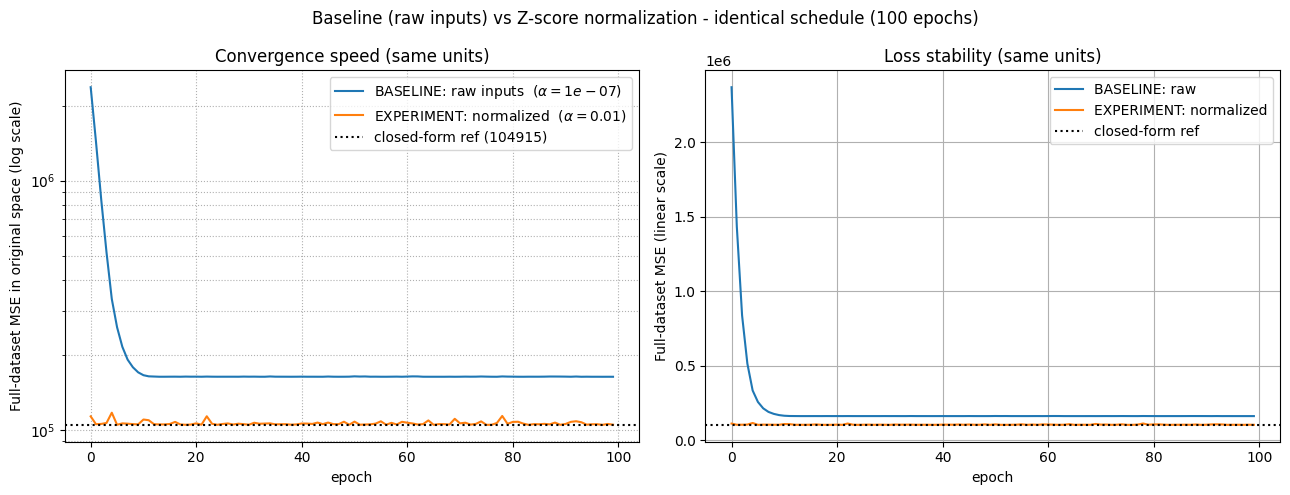

In [ ]:
# Convergence comparison in the SAME units (original CHF^2 space).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel - log scale to compare convergence rate.
axes[0].plot(loss_full_raw,  label=f"BASELINE: raw inputs  ($\\alpha={alpha_raw}$)")
axes[0].plot(loss_full_norm, label=f"EXPERIMENT: normalized  ($\\alpha={alpha_norm}$)")
axes[0].axhline(J_ref_n, color="black", linestyle=":",
                label=f"closed-form ref ({J_ref_n:.0f})")
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Full-dataset MSE in original space (log scale)")
axes[0].set_title("Convergence speed (same units)")
axes[0].legend(); axes[0].grid(True, which="both", linestyle=":")

# Right panel - linear scale to make stability visible.
axes[1].plot(loss_full_raw,  label="BASELINE: raw")
axes[1].plot(loss_full_norm, label="EXPERIMENT: normalized")
axes[1].axhline(J_ref_n, color="black", linestyle=":", label="closed-form ref")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("Full-dataset MSE (linear scale)")
axes[1].set_title("Loss stability (same units)")
axes[1].legend(); axes[1].grid(True)

fig.suptitle("Baseline (raw inputs) vs Z-score normalization - identical schedule (100 epochs)")
fig.tight_layout()
plt.show()


**Observations - normalization vs the un-normalized baseline.**

This subsection treats the **un-normalised, raw-data SGD run as the baseline**
(it is precisely the configuration established in Sections 1-5 and used in
Sections 6.1, 6.3, and 6.4), and evaluates Z-score normalisation as an
*experimental modification* applied to a separate copy of the data.

- **Apples-to-apples comparison.** Plotting both losses in the same
  original-CHF$^2$ space removes the unit mismatch: a normalised loss of $0.4$
  is meaningless next to a CHF$^2$ loss of $150\,000$, but the *projected*
  original-space MSE of the normalised run is directly comparable to the
  baseline.
- **Convergence speed.** Under the baseline (raw) configuration, the loss is
  still drifting after 100 epochs and ends at $J \approx 163\,510$ — about
  56% above the closed-form optimum ($J_{\text{ref}} \approx 104\,915$). The
  same model on normalised inputs reaches the basin of the optimum within
  roughly ten epochs and ends at $J \approx 105\,069$ — a ~0.15% deviation.
  Measured by *deviation from the optimum*, the normalised run is roughly
  $380\times$ closer than the baseline (gap ~154 vs ~58 600), i.e., **more
  than two orders of magnitude better** under the same model, the same data,
  and the same number of updates. The only difference is the input scale (and
  the learning rate that necessarily accompanies it).
- **Convergence stability.** The baseline curve is jagged whereas the
  normalised curve is nearly monotone. This is a geometric consequence: with
  raw inputs the loss landscape is a highly elongated ellipse whose long axis
  lies along $\theta_0$ and short axis along $\theta_1$ (the Hessian
  eigenvalues differ by a factor of $\sim \overline{x^2}$); plain SGD
  oscillates along the short axis while crawling along the long one.
  Normalisation approximately circularises the level sets, so a *single*
  $\alpha$ produces well-behaved descent along both axes simultaneously —
  without the per-parameter-LR machinery the baseline requires in Sections
  6.1, 6.3, and 6.4.
- **Interpretation in context.** Sections 6.1, 6.3, and 6.4 all converge on
  raw inputs by introducing per-parameter learning rates (Section 5.1
  baseline). This subsection identifies the *alternative* path: instead of
  giving each parameter its own $\alpha$, one can re-condition the data so
  that a single $\alpha$ suffices. Both approaches address the same
  underlying problem — the disparate gradient scales induced by un-normalised
  features — and the choice between them is a matter of pipeline
  architecture, not of mathematical necessity.



---
*Use of Generative AI was used for code structure, text editing, and report formatting assistance.
All experimental design and analysis was performed by the group members.*